In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [20]:
names = open('data/names.txt', 'r').read().splitlines()
names[:5]

['rosaline', 'jami-pekka', 'meemi', 'sävele', 'mawada']

In [62]:
vocabulary = sorted(list(set(''.join(names))))
vocabulary.insert(0, '<S>')
vocabulary.insert(1, '<E>')
len(vocabulary)

54

In [63]:
atoi = {c: i for i, c in enumerate(vocabulary)}
itoa = {i: c for i, c in enumerate(vocabulary)}

In [ ]:
block_size = 8

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * 8
    for i in range(len(w) + 1):
      ch = w[i] if i < len(w) else '<E>'
      ix = atoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)

  return X, Y

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))
Xtr,  Ytr  = build_dataset(names[:n1])     # 80%
Xdev, Ydev = build_dataset(names[n1:n2])   # 10%
Xte,  Yte  = build_dataset(names[n2:])     # 10%

torch.Size([146520, 8]) torch.Size([146520])
torch.Size([18287, 8]) torch.Size([18287])
torch.Size([18450, 8]) torch.Size([18450])


In [65]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itoa[int(ix.item())] for ix in x), '-->', itoa[int(y.item())])

<S><S><S><S><S><S><S><S> --> r
<S><S><S><S><S><S><S>r --> o
<S><S><S><S><S><S>ro --> s
<S><S><S><S><S>ros --> a
<S><S><S><S>rosa --> l
<S><S><S>rosal --> i
<S><S>rosali --> n
<S>rosalin --> e
rosaline --> <E>
<S><S><S><S><S><S><S><S> --> j
<S><S><S><S><S><S><S>j --> a
<S><S><S><S><S><S>ja --> m
<S><S><S><S><S>jam --> i
<S><S><S><S>jami --> -
<S><S><S>jami- --> p
<S><S>jami-p --> e
<S>jami-pe --> k
jami-pek --> k
ami-pekk --> a
mi-pekka --> <E>


In [ ]:
class CausalDilatedConv1d(nn.Module):

    def __init__(self, in_channels: int, out_channels: int, dilation: int = 1):
        super().__init__()
        kernel_size = 2
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels,
            out_channels * 2,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=0,
        )
        self.residual_conv = nn.Conv1d(out_channels, out_channels, kernel_size=1)
        self.skip_conv     = nn.Conv1d(out_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor):
        h = F.pad(x, (self.padding, 0))
        h = self.conv(h)

        h_tanh, h_sig = h.chunk(2, dim=1)
        h = torch.tanh(h_tanh) * torch.sigmoid(h_sig)

        skip     = self.skip_conv(h)
        residual = self.residual_conv(h) + x
        return residual, skip

class WaveNetChar(nn.Module):
    
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int  = 64,
        channels: int   = 128,
        num_layers: int = 3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.input_conv = nn.Conv1d(embed_dim, channels, kernel_size=1)

        self.layers = nn.ModuleList([
            CausalDilatedConv1d(channels, channels, dilation=2**i)
            for i in range(num_layers)
        ])

        self.output_head = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(channels, vocab_size, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.embedding(x).transpose(1, 2)
        h = self.input_conv(h)

        skip_sum = torch.zeros_like(h)
        for layer in self.layers:
            h, skip = layer(h)
            skip_sum = skip_sum + skip

        logits = self.output_head(skip_sum)
        return logits


@torch.no_grad()
def generate(model, stoi, itos, seed: str, length: int = 200, temperature: float = 0.8):
    model.eval()

    context = 8

    indices = [stoi.get(c, 0) for c in seed[-context:]]
    indices = [0] * (context - len(indices)) + indices
    ctx = torch.tensor(indices, dtype=torch.long).unsqueeze(0)

    result = seed
    for _ in range(length):
        logits = model(ctx)
        logits = logits[:, :, -1] / temperature
        probs  = F.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        next_char = itos[next_idx.item()]

        if next_char == '<E>':
            break

        result  += next_char

        ctx = torch.cat([ctx[:, 1:], next_idx], dim=1)

    return result


In [197]:
CONTEXT     = 8
EMBED_DIM   = 32
CHANNELS    = 128
BATCH_SIZE  = 64
EPOCHS      = 10_000
LR          = 1e-4

vocab_size = len(vocabulary)

print(f"Vocabulary size: {vocab_size}")
print(f"Training samples: {len(Xtr)}")

losses = []
val_losses = []

model = WaveNetChar(vocab_size, embed_dim=EMBED_DIM, channels=CHANNELS, num_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")

for epoch in range(1, EPOCHS + 1):
    model.train()

    idx  = torch.randint(0, len(Xtr), (BATCH_SIZE,))
    xb, yb = Xtr[idx], Ytr[idx]

    logits = model(xb)
    logits = logits[:, :, -1]

    loss = F.cross_entropy(logits, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        with torch.no_grad():
            model.eval()

            dev_logits = model(Xdev)
            dev_logits = dev_logits[:, :, -1]
            dev_loss = F.cross_entropy(dev_logits, Ydev)
            val_losses.append(dev_loss.item())

        print(f"Epoch {epoch:4d} | loss {loss.item():.4f} | dev loss {dev_loss.item():.4f}")


Vocabulary size: 54
Training samples: 146520
Parameters: 325,878
Epoch  500 | loss 2.6021 | dev loss 2.4854
Epoch 1000 | loss 2.3167 | dev loss 2.3784
Epoch 1500 | loss 2.2809 | dev loss 2.3208
Epoch 2000 | loss 2.1785 | dev loss 2.2844
Epoch 2500 | loss 2.4105 | dev loss 2.2494
Epoch 3000 | loss 2.2364 | dev loss 2.2300
Epoch 3500 | loss 2.2624 | dev loss 2.2029
Epoch 4000 | loss 2.4363 | dev loss 2.1850
Epoch 4500 | loss 2.3601 | dev loss 2.1724
Epoch 5000 | loss 1.9782 | dev loss 2.1501
Epoch 5500 | loss 2.3088 | dev loss 2.1395
Epoch 6000 | loss 2.4354 | dev loss 2.1286
Epoch 6500 | loss 1.9885 | dev loss 2.1173
Epoch 7000 | loss 2.0173 | dev loss 2.1081
Epoch 7500 | loss 1.9189 | dev loss 2.0932
Epoch 8000 | loss 2.0313 | dev loss 2.0887
Epoch 8500 | loss 2.2970 | dev loss 2.0781
Epoch 9000 | loss 2.1528 | dev loss 2.0699
Epoch 9500 | loss 1.9069 | dev loss 2.0616
Epoch 10000 | loss 1.9500 | dev loss 2.0528


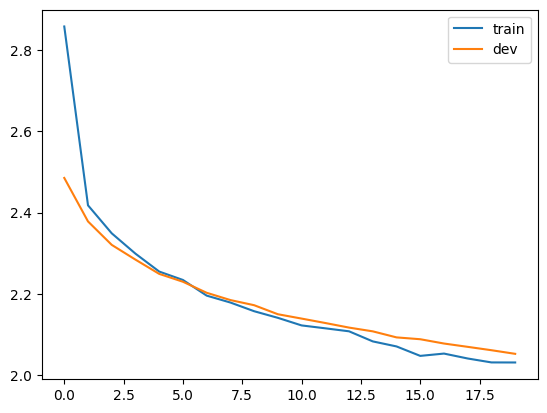

In [198]:
plt.plot(torch.tensor(losses).view(-1, 500).mean(dim=1))
plt.plot(torch.tensor(val_losses))
plt.legend(['train', 'dev'])

In [199]:
for i in range(10):
    print(generate(model, atoi, itoa, seed="<S>").strip('<S>'))

jodesse
shelie
mubin
maurim
maamel
seaso
biannia
sadgali
hanna
vilfer


In [200]:
# Test set evaluation
with torch.no_grad():
    model.eval()

    test_logits = model(Xte)
    test_logits = test_logits[:, :, -1]
    test_loss = F.cross_entropy(test_logits, Yte)
    
    print(f"Test loss: {test_loss.item():.4f}")

Test loss: 2.0351
